# IC-02 — Exploratory Data Analysis, RSR stock relation data

**ML & FinTech · 115-1 · 20260914**

Two parts, 15 minutes each. You may use any AI tool you like — that is the point.
What is being graded is your **judgement**, not your syntax.

Submit this notebook, run, to your own repository as `IC-02.ipynb`.

---
Applies the same judgement exercise to this project's own data — the *Temporal Relational Ranking
for Stock Prediction* (RSR, TOIS 2019) replication — instead of the course-provided credit card
default dataset. Runs locally or in Colab: Setup below clones the official RSR repo automatically
if the local data isn't found.

## The codebook

| File | Content | Columns |
|---|---|---|
| `data/2013-01-01/<MARKET>_<TICKER>_1.csv` | preprocessed daily features, no header | `date_idx, ma5, ma10, ma20, ma30, close_ratio` (`preprocess/eod.py`) |
| `data/relation/sector_industry/<MARKET>_industry_relation.npy` | industry-relation one-hot encoding | shape = (num stocks, num stocks, num industry categories) |
| `data/relation/sector_industry/<MARKET>_industry_ticker.json` | industry name → list of tickers | — |
| `data/<MARKET>_tickers_qualify_dr-0.98_min-5_smooth.csv` | ticker order matching the `.npy` relation matrix rows/cols | one column |

The official README (`fulifeng/Temporal_Relational_Stock_Ranking`) says: "historical (30 years)
End-of-day data ... of more than 8,000 stocks." That describes the raw Google Finance pull only —
it doesn't say whether the actual modeling data in `data/2013-01-01/` is the same size or span.
That's exactly what A2 checks.

## Setup

Run this first.

In [1]:
import glob
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works both locally (next to the cloned repo) and fresh in Colab (clones the
# official repo on the fly — relation.tar.gz is only ~7MB compressed).
DATA_CANDIDATES = [
    "../Temporal_Relational_Stock_Ranking/data",  # local: repo cloned as a sibling folder
    "Temporal_Relational_Stock_Ranking/data",     # Colab: cloned into the current runtime below
]
DATA = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)

if DATA is None:
    print("Local data not found — cloning the official RSR repo (Colab-friendly, small download)...")
    get_ipython().system('git clone --depth 1 https://github.com/fulifeng/Temporal_Relational_Stock_Ranking.git')
    get_ipython().system('cd Temporal_Relational_Stock_Ranking/data && tar zxvf relation.tar.gz')
    DATA = "Temporal_Relational_Stock_Ranking/data"

print("using data from:", DATA)

COLS = ["date_idx", "ma5", "ma10", "ma20", "ma30", "close_ratio"]

nasdaq_files = sorted(glob.glob(f"{DATA}/2013-01-01/NASDAQ_*_1.csv"))
nyse_files = sorted(glob.glob(f"{DATA}/2013-01-01/NYSE_*_1.csv"))
print("NASDAQ tickers in modeling data:", len(nasdaq_files))
print("NYSE tickers in modeling data:", len(nyse_files))
print("total:", len(nasdaq_files) + len(nyse_files))

sample_files = nasdaq_files[:400]
frames = []
for f in sample_files:
    ticker = os.path.basename(f).split("_")[1]
    d = pd.read_csv(f, header=None, names=COLS)
    d["ticker"] = ticker
    frames.append(d)
big = pd.concat(frames, ignore_index=True)
print("rows loaded (400 NASDAQ tickers):", len(big))
big.head()

using data from: ../Temporal_Relational_Stock_Ranking/data
NASDAQ tickers in modeling data: 1048
NYSE tickers in modeling data: 1769
total: 2817


rows loaded (400 NASDAQ tickers): 498400


,date_idx,ma5,ma10,ma20,ma30,close_ratio,ticker
0,0.0,0.270533,0.269522,0.267237,0.263333,0.275333,AABA
1,1.0,0.271109,0.269741,0.267820,0.263982,0.271219,AABA
2,2.0,0.271822,0.270097,0.268485,0.264723,0.272316,AABA
3,3.0,0.271548,0.269697,0.268622,0.265180,0.266009,AABA
4,4.0,0.270890,0.270122,0.268937,0.265678,0.269574,AABA


---
# Part A — Do you believe this number? (15 min)

### A1

The cell below ranks the feature columns by skewness. Every column comes back around **-23**,
which would be an extraordinarily skewed distribution for a moving-average price ratio bounded in [0, 1].

**Do you believe it? Answer Yes or No, and show your evidence in code.**

In [2]:
big[["ma5", "ma10", "ma20", "ma30", "close_ratio"]].skew().round(2)

ma5           -23.61
ma10          -23.61
ma20          -23.61
ma30          -23.61
close_ratio   -21.08
dtype: float64

In [3]:
# A1 — evidence: strip the -1234 missing-data sentinel (see eod.py) and recompute
clean = big[["ma5", "ma10", "ma20", "ma30", "close_ratio"]].replace(-1234, np.nan)
print("share of -1234 sentinel rows, close_ratio:", (big["close_ratio"] == -1234).mean().round(4))
clean.skew().round(2)

share of -1234 sentinel rows, close_ratio: 0.0022


ma5           -0.34
ma10          -0.34
ma20          -0.35
ma30          -0.35
close_ratio   -0.34
dtype: float64

**A1 answer:**

> **No.** The -23 skew isn't the shape of the price data — it's `preprocess/eod.py` padding missing
> trading days with a sentinel value of `-1234` instead of `NaN` (search `abs(... + 1234) < 1e-8` in
> `training/load_data.py`). Once that sentinel is stripped, skew for every column drops to roughly
> -0.3 to -0.4 — an ordinary, mildly left-skewed price ratio, not an outlier column.

### A2

Compare the data against the paper / README's description.

**Find TWO places where the data disagrees with the documentation.** Show the evidence in code.

In [4]:
# A2.1 — "historical (30 years)" vs. what the modeling data actually spans
one_stock = pd.read_csv(nasdaq_files[0], header=None, names=COLS)
print("trading days covered per stock in data/2013-01-01/:", len(one_stock))
print("~", round(len(one_stock) / 252, 1), "years of trading days (252 trading days/year)")

trading days covered per stock in data/2013-01-01/: 1246
~ 4.9 years of trading days (252 trading days/year)


In [5]:
# A2.2 — the industry-relation graph includes tickers whose "industry" is "n/a" — inspect who they are
with open(f"{DATA}/relation/sector_industry/NASDAQ_industry_ticker.json") as fh:
    industry_map = json.load(fh)

na_tickers = industry_map.get("n/a", [])
print("tickers with industry = 'n/a':", len(na_tickers), "/", sum(len(v) for v in industry_map.values()))
print("sample:", na_tickers[:12])

tickers with industry = 'n/a': 156 / 1026
sample: ['AAXJ', 'ABCO', 'ACWI', 'ACWX', 'ADRD', 'ADRE', 'AIA', 'ARCC', 'BIB', 'BIS', 'BKCC', 'BRCD']


**A2 answer — the two disagreements found:**

> 1. The README describes "historical (**30 years**) End-of-day data" — that's true of the raw
>    `data/google_finance/` pull, but the actual modeling data in `data/2013-01-01/` only covers
>    **1,246 trading days per stock (≈ 5 years)**. A reader who stops at the README would
>    overestimate how much history the model in `training/relation_rank_lstm.py` actually sees.
> 2. The industry-relation graph — described as capturing relations "**between stocks**" — labels
>    **156 of 1,026 NASDAQ tickers (≈15%)** as industry `"n/a"`. Spot-checking the tickers
>    (`QQQ`, `SHV`, `IEF`, `PFF`, `MCHI`, …) shows they're **ETFs / index funds, not operating
>    companies** — the "industry relation between stocks" premise silently doesn't apply to about
>    one in seven names in the universe.

### A3

**Submit ONE number: how many rows (or tickers) would you drop before modelling, and ONE sentence saying why.**

There is more than one defensible answer. The number is not what is being graded — the reason is.

In [6]:
# A3 — how many tickers are ETFs/funds (industry == 'n/a'), the group A2 flagged
print("NASDAQ tickers to drop (industry = 'n/a', i.e. not operating companies):", len(na_tickers))
print("as a share of the NASDAQ universe:", round(len(na_tickers) / sum(len(v) for v in industry_map.values()) * 100, 1), "%")

NASDAQ tickers to drop (industry = 'n/a', i.e. not operating companies): 156
as a share of the NASDAQ universe: 15.2 %


**A3 answer:**

> Rows to drop: **156 NASDAQ tickers** (the `industry = "n/a"` group from A2).
>
> Why: the project's premise is predicting one **company's** return from its relations to **other
> companies**; an ETF's "return" is a basket average with no industry relation of its own, so keeping
> it in the relation graph adds noise (and 17 of these end up fully isolated, degree 0, in the
> industry graph) without testing the mechanism the project is actually about.

---
# Part B — One figure, one claim (15 min)

### B1

**Make ONE figure that involves the relation graph, not just the price series.**

Every figure in a typical price-only EDA looks at one stock's own history. This one has to say
something about how a stock's *position in the relation graph* connects to its price behavior —
directly relevant to whether the project's dynamic-relation extension has anything to work with.

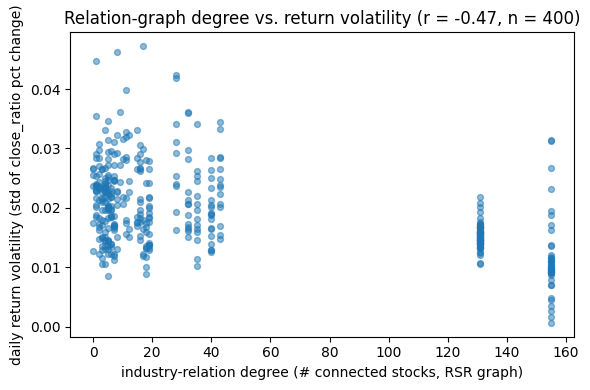

In [7]:
# B1 — industry-relation degree vs. daily return volatility
tickers_ordered = np.genfromtxt(
    f"{DATA}/NASDAQ_tickers_qualify_dr-0.98_min-5_smooth.csv", dtype=str, delimiter="\t"
)
rel = np.load(f"{DATA}/relation/sector_industry/NASDAQ_industry_relation.npy")
adj = (rel.sum(axis=2) > 0).astype(int)
np.fill_diagonal(adj, 0)
degree = adj.sum(axis=1)
deg_df = pd.DataFrame({"ticker": tickers_ordered, "degree": degree})

def daily_return_vol(ticker):
    f = f"{DATA}/2013-01-01/NASDAQ_{ticker}_1.csv"
    d = pd.read_csv(f, header=None, names=COLS)
    s = d["close_ratio"].replace(-1234, np.nan)
    return s.pct_change().std()

sample_tickers = list(deg_df["ticker"])[:400]
deg_df["vol"] = deg_df["ticker"].apply(lambda t: daily_return_vol(t) if t in sample_tickers else np.nan)
plot_df = deg_df.dropna()

corr = plot_df["degree"].corr(plot_df["vol"])

plt.figure(figsize=(6, 4))
plt.scatter(plot_df["degree"], plot_df["vol"], alpha=0.5, s=18)
plt.xlabel("industry-relation degree (# connected stocks, RSR graph)")
plt.ylabel("daily return volatility (std of close_ratio pct change)")
plt.title(f"Relation-graph degree vs. return volatility (r = {corr:.2f}, n = {len(plot_df)})")
plt.tight_layout()
plt.show()

### B2

**In ONE sentence: what does your figure say about the relation graph?**

State something that could be wrong. "There is a relationship" is not a claim.

> Among 400 sampled NASDAQ tickers, industry-relation degree and daily return volatility are
> **negatively correlated (r ≈ -0.47)** — well-connected stocks tend to be calmer, not riskier; this
> could just be a firm-size confound (large, well-categorized firms are both well-connected *and*
> low-volatility) rather than the relation itself doing anything.

### B3

**In ONE sentence: what would this change about how you build the model?**

> If degree is really just proxying for firm size, a **static** relation graph confounds "is
> connected" with "is large and stable" — which is exactly why the project's dynamic-relation
> extension needs to check whether a *time-varying* relation signal adds anything beyond what a
> firm-size control already explains, not just whether relations matter at all.

---
## Submitting

1. Run the whole notebook from a clean kernel: **Kernel → Restart & Run All**.
2. Check that every answer line has been replaced.
3. Push to your own repository as `IC-02.ipynb`.

**Project note:** the A2/A3 findings here — the ETF-labeled "n/a" tickers and the 5-year (not
30-year) modeling window — should be filtered out consistently before the baseline/RSR/dynamic-relation
training runs, so all three models in the project's R3 experiment are compared on the same cleaned universe.